# 04 - Statistical Analysis

Objective: Run correlation, regression, and hypothesis tests using Blinkit cleaned data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid')
except Exception:
    sns = None

try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

DATA_PATH = '../data/processed/blinkit_cleaned_dashboard_data.csv'
df = pd.read_csv(DATA_PATH)

for c in ['order_date', 'promised_time', 'actual_time', 'feedback_date']:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors='coerce')

order_level = df.sort_values('order_date').drop_duplicates('order_id').copy()

print(f'Rows (line-item): {len(df):,}')
print(f'Rows (order-level): {len(order_level):,}')
print(f'SciPy available: {SCIPY_AVAILABLE}')

Rows (line-item): 5,000
Rows (order-level): 5,000
SciPy available: True


## Correlation Analysis

,order_total,quantity,unit_price,total_price,rating,distance_km,delay_minutes,actual_duration_minutes,promised_duration_minutes,delivery_efficiency
order_total,1.000,-0.005,-0.010,-0.008,-0.009,-0.014,0.002,-0.004,-0.005,0.010
quantity,-0.005,1.000,0.020,0.540,0.001,0.003,0.020,0.033,0.045,-0.008
unit_price,-0.010,0.020,1.000,0.790,-0.006,0.010,-0.001,0.004,0.018,0.002
total_price,-0.008,0.540,0.790,1.000,-0.005,0.011,0.004,0.015,0.039,0.003
rating,-0.009,0.001,-0.006,-0.005,1.000,0.009,0.002,-0.005,-0.013,-0.000
distance_km,-0.014,0.003,0.010,0.011,0.009,1.000,0.004,0.003,-0.003,-0.005
delay_minutes,0.002,0.020,-0.001,0.004,0.002,0.004,1.000,0.916,-0.001,-0.794
actual_duration_minutes,-0.004,0.033,0.004,0.015,-0.005,0.003,0.916,1.000,0.364,-0.823
promised_duration_minutes,-0.005,0.045,0.018,0.039,-0.013,-0.003,-0.001,0.364,1.000,-0.011
delivery_efficiency,0.010,-0.008,0.002,0.003,-0.000,-0.005,-0.794,-0.823,-0.011,1.000


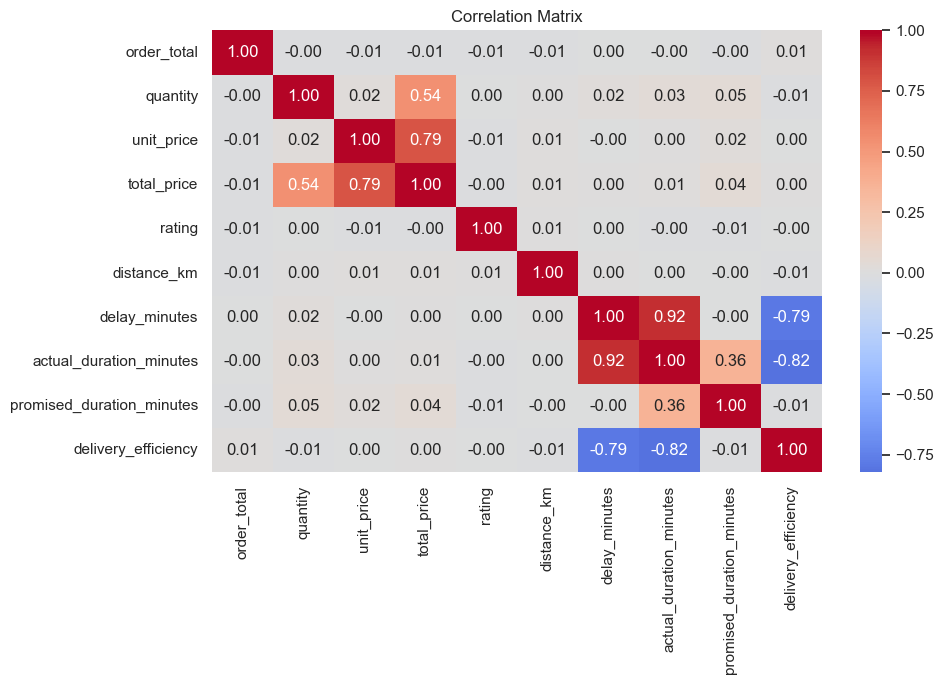

In [2]:
corr_cols = [
    'order_total', 'quantity', 'unit_price', 'total_price', 'rating',
    'distance_km', 'delay_minutes', 'actual_duration_minutes',
    'promised_duration_minutes', 'delivery_efficiency'
]
corr_cols = [c for c in corr_cols if c in order_level.columns]

corr_df = order_level[corr_cols].corr(numeric_only=True)
display(corr_df.round(3))

plt.figure(figsize=(10, 7))
if sns is not None:
    sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', center=0)
else:
    plt.imshow(corr_df, cmap='coolwarm', aspect='auto')
    plt.colorbar()
    plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=45, ha='right')
    plt.yticks(range(len(corr_df.index)), corr_df.index)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## Regression Analysis (Order Total Prediction)

,feature,coefficient
0,intercept,2316.129396
1,quantity,-6.915790
2,unit_price,-0.041789
3,distance_km,-13.547745
4,actual_duration_minutes,-0.577732
5,rating,-9.487283


R^2: 0.0004


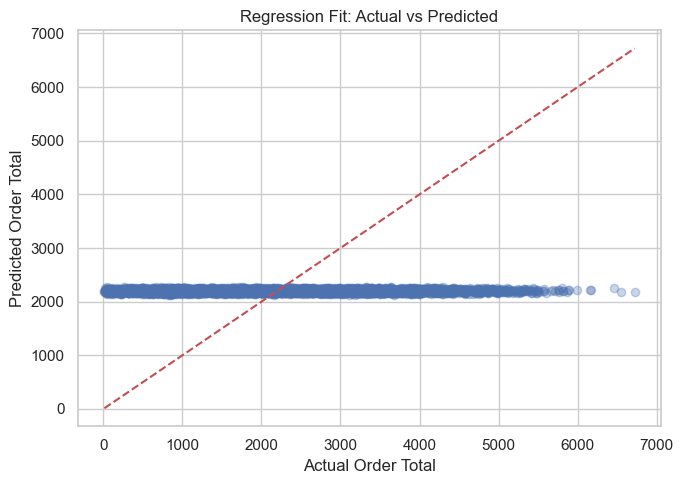

In [3]:
feature_cols = ['quantity', 'unit_price', 'distance_km', 'actual_duration_minutes', 'rating']
feature_cols = [c for c in feature_cols if c in order_level.columns]

reg_df = order_level[feature_cols + ['order_total']].dropna().copy()

X = reg_df[feature_cols].to_numpy()
y = reg_df['order_total'].to_numpy()

X_design = np.column_stack([np.ones(len(X)), X])
beta, residuals, rank, s = np.linalg.lstsq(X_design, y, rcond=None)
y_pred = X_design @ beta

ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

coef_table = pd.DataFrame({
    'feature': ['intercept'] + feature_cols,
    'coefficient': beta
})

display(coef_table)
print(f'R^2: {r2:.4f}')

plt.figure(figsize=(7, 5))
plt.scatter(y, y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual Order Total')
plt.ylabel('Predicted Order Total')
plt.title('Regression Fit: Actual vs Predicted')
plt.tight_layout()
plt.show()

## Hypothesis Testing

In [4]:
results = []

# Test 1: Difference in average order value for delayed vs non-delayed orders
if {'is_delayed', 'order_total'}.issubset(order_level.columns):
    grp_delayed = order_level.loc[order_level['is_delayed'] == True, 'order_total'].dropna()
    grp_ontime = order_level.loc[order_level['is_delayed'] == False, 'order_total'].dropna()

    if SCIPY_AVAILABLE and len(grp_delayed) > 2 and len(grp_ontime) > 2:
        t_stat, p_val = stats.ttest_ind(grp_delayed, grp_ontime, equal_var=False)
        results.append({
            'test': 'Welch t-test: delayed vs non-delayed order_total',
            'statistic': t_stat,
            'p_value': p_val,
            'significant_5pct': p_val < 0.05
        })

# Test 2: ANOVA across customer segments for order_total
if {'customer_segment', 'order_total'}.issubset(order_level.columns):
    seg_groups = [g['order_total'].dropna().values for _, g in order_level.groupby('customer_segment')]
    seg_groups = [g for g in seg_groups if len(g) > 2]

    if SCIPY_AVAILABLE and len(seg_groups) >= 3:
        f_stat, p_val = stats.f_oneway(*seg_groups)
        results.append({
            'test': 'ANOVA: order_total by customer_segment',
            'statistic': f_stat,
            'p_value': p_val,
            'significant_5pct': p_val < 0.05
        })

# Test 3: Chi-square for payment_method vs is_delayed
if {'payment_method', 'is_delayed'}.issubset(order_level.columns) and SCIPY_AVAILABLE:
    ctab = pd.crosstab(order_level['payment_method'], order_level['is_delayed'])
    if ctab.shape[0] >= 2 and ctab.shape[1] >= 2:
        chi2, p_val, dof, exp = stats.chi2_contingency(ctab)
        results.append({
            'test': 'Chi-square: payment_method vs is_delayed',
            'statistic': chi2,
            'p_value': p_val,
            'significant_5pct': p_val < 0.05
        })

if len(results) == 0:
    print('No statistical tests executed (missing fields or SciPy not available).')
else:
    display(pd.DataFrame(results))

,test,statistic,p_value,significant_5pct
0,Welch t-test: delayed vs non-delayed order_total,0.379032,0.704684,False
1,ANOVA: order_total by customer_segment,2.519909,0.056168,False
2,Chi-square: payment_method vs is_delayed,3.579838,0.310554,False
